# [DRIVE] UNet -- AGG FOLD LOOPS -- seed 1337

In [1]:
import sys, os
sys.path.append(os.path.abspath('../../'))

print( os.getcwd())
sys.path


c:\Users\s1005\OneDrive\文件\PLM_DOCS\code\githubs\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\notebooks\train_all


['C:\\Users\\s1005\\AppData\\Local\\Programs\\Python\\Python310\\python310.zip',
 'C:\\Users\\s1005\\AppData\\Local\\Programs\\Python\\Python310\\DLLs',
 'C:\\Users\\s1005\\AppData\\Local\\Programs\\Python\\Python310\\lib',
 'C:\\Users\\s1005\\AppData\\Local\\Programs\\Python\\Python310',
 'c:\\Users\\s1005\\OneDrive\\文件\\PLM_DOCS\\code\\githubs\\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\\venv_310_1',
 '',
 'c:\\Users\\s1005\\OneDrive\\文件\\PLM_DOCS\\code\\githubs\\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\\venv_310_1\\lib\\site-packages',
 'c:\\Users\\s1005\\OneDrive\\文件\\PLM_DOCS\\code\\githubs\\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation']

In [2]:
from src.models.unet import UNet
print(UNet)

<class 'src.models.unet.UNet'>


In [3]:
from pathlib import Path
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# CHANGE THESE

In [4]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED   = 1337
DATASET = "DRIVE" # "DRIVE" | "STARE" | "CHASEDB1"

PATCH_SIZE = 128
VAL_WINDOW  = PATCH_SIZE
VAL_OVERLAP = 0.25

VESSEL_BIAS=0.7
MIN_PERCENT_VESSEL=0.008
V_MULT=30
DENSE_BIAS=None
BATCH_SIZE=2

IMG_SIZE=512

EPOCHS = 4
warmup_epochs = 5

FOLDS = 2
FOLD_ID = 0

THRESHOLD_EVAL = 0.5


MODEL_NAME = "LadderNet"
TITLE     = f"[{DATASET}] {MODEL_NAME} NEW SPLIT ({FOLDS} folds) epochs={EPOCHS}"
SAVE_ROOT = Path(f"../../../../pth/{MODEL_NAME}_{DATASET}_NEWSPLIT")     # a clean experiment folder
SAVE_CKPT = SAVE_ROOT / "checkpoints"
SAVE_PRED = SAVE_ROOT / "predictions"   # per-image logits/prob/masks
SAVE_VIZ  = SAVE_ROOT / "visuals"       # PNG overlays per test image
SAVE_LOGS = SAVE_ROOT / "logs"
for d in [SAVE_ROOT, SAVE_CKPT, SAVE_PRED, SAVE_VIZ, SAVE_LOGS]: d.mkdir(parents=True, exist_ok=True)

DATASET_ROOT        = f"../../../../Retinal_Vessel_Segmentation_Datasets/{DATASET}/"
DATASET_LABELFOLDER = "1st_manual"




# IMPORTS

In [5]:
import os, json, math, time, random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import LambdaLR
import matplotlib.pyplot as plt

# --- data utils ---
from src.data.splits import (
    split_drive_20_20,
    split_chase_subjectwise_20_8,
    split_stare_leave_one_out,
    stare_loo_fold,
    chase_mc_balanced_splits,
    drive_mc_balanced_splits,

    chase_random_subject_split,

)

from src.data.dataloader import make_loaders
from src.data.augmentations import get_train_augs, get_val_augs

# use YOUR metrics utilities
from src.training.metrics import (
    confusion_counts,
    dice as dice_metric,
    iou as iou_metric,
    roc_auc as roc_auc_metric,
    pr_auc as pr_auc_metric,
    acc_from_counts,
    recall_from_counts,          # sensitivity
    specificity_from_counts,     # specificity
    cldice
)


from src.training.train_cv import (
    sliding_window_forward_logits,
    update_dataset,
    #train_one_epoch,
    #validate_loss_only,
    #atomic_torch_save,
    saveTrainVal
)


# --- evaluation & visualization ---
from src.evaluation.evaluate import evaluate_and_print
from src.evaluation.visualization import visualize_samples

c:\Users\s1005\OneDrive\文件\PLM_DOCS\code\githubs\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\venv_310_1\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# helpers and config

In [6]:
splits, counts = drive_mc_balanced_splits(
    DATASET_ROOT, label_folder=DATASET_LABELFOLDER, n_runs=FOLDS
)

[DRIVE] Run 00 TEST images: ['31_training.png', '27_training.png', '33_training.png', '40_training.png', '35_training.png', '04_test.png', '30_training.png', '20_test.png', '11_test.png', '24_training.png', '38_training.png', '08_test.png', '25_training.png', '19_test.png', '01_test.png', '13_test.png', '14_test.png', '36_training.png', '39_training.png', '06_test.png']
[DRIVE] Run 01 TEST images: ['11_test.png', '28_training.png', '32_training.png', '08_test.png', '02_test.png', '26_training.png', '38_training.png', '29_training.png', '05_test.png', '16_test.png', '25_training.png', '19_test.png', '39_training.png', '03_test.png', '04_test.png', '21_training.png', '12_test.png', '20_test.png', '27_training.png', '23_training.png']
[DRIVE] Final per-image test counts: {0: 1, 1: 0, 2: 1, 3: 1, 4: 2, 5: 1, 6: 2, 7: 1, 8: 1, 9: 1, 10: 1, 11: 1, 12: 1, 13: 0, 14: 1, 15: 1, 16: 0, 17: 2, 18: 2, 19: 1, 20: 1, 21: 1, 22: 1, 23: 2, 24: 1, 25: 1, 26: 0, 27: 2, 28: 0, 29: 0, 30: 2, 31: 1, 32: 1,

In [7]:
# --- model factory (fresh per fold) ---


def make_model(MODEL_NAME, train_loader = None) -> nn.Module:
    if MODEL_NAME == "MATHFI":
        # --- loss ---
        from src.models.wrappers.dpcn_concat_unet import DPCNConcatUNet
        BASE_KW = {"cbam_reduction": 16}

        if train_loader is not None:
            from src.training.loss_functions import DiceBCEComplementLoss

            def estimate_class_weights(loader, max_batches=20):
                with torch.no_grad():
                    s = 0.0; n = 0
                    for i, b in enumerate(loader):
                        s += b["mask"].float().mean().item(); n += 1
                        if i+1 >= max_batches: break
                p = max(1e-6, min(1-1e-6, s / max(1, n)))
                w1 = 1.0 / p; w0 = 1.0 / (1.0 - p)
                s2 = w0 + w1; w0 = 2.0 * w0 / s2; w1 = 2.0 * w1 / s2
                return w0, w1

            w0, w1 = estimate_class_weights(train_loader, max_batches=20)
            loss_fn = DiceBCEComplementLoss(w0=w0, w1=w1, dice_weight=0.5, bce_weight=0.5,
                                        exact_equation=False, reduction="mean")

        else: loss_fn = None
        # --- model ---
        return DPCNConcatUNet(
            in_ch=1, enh_channels=64, iters=6,
            threshold_mode="scaled_vat", half_life=2.0,
            reduce_to=64, base_kwargs=BASE_KW
        ).to(DEVICE), loss_fn

    elif MODEL_NAME == "FR-UNet":
        sys.path.append(os.path.abspath('../../../FR-UNet/'))
        loss_fn = nn.BCEWithLogitsLoss()
        from models.fr_unet import FR_UNet
        return FR_UNet().to(DEVICE), loss_fn

    elif MODEL_NAME == "UNet":
      from src.models.orig_unet import UNet
      model = UNet(in_channels=1, out_channels=2).to(DEVICE)
      class_weights = torch.tensor([1.30, 1.70], device=DEVICE)  # was ~[1.55,1.65] → ease BG tilt
      loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)  # no label_smoothing
      return model, loss_fn
    
    elif MODEL_NAME == "LadderNet":
        from LadderNet import LadderNetv6
        layers = 4
        filters = 10
        model = LadderNetv6(
            num_classes=2,layers=layers,filters=filters,inplanes=1).to(DEVICE)
        return  model, torch.nn.CrossEntropyLoss()
                
    elif MODEL_NAME == "LWNet":
        from LWNet import WNet
        model_core = WNet(in_c=1,
                  n_classes=2,
                  layers=(8,16,32),
                  k_sz=3,
                  up_mode='transp_conv',
                  conv_bridge=True,
                  shortcut=True).to(DEVICE)
        
        return model_core, torch.nn.CrossEntropyLoss()

def add_metrics(model_name, root, label_folder, img_size, ckpt_path, threshold_eval, all_metrics):


        stem = Path(ckpt_path).stem  # "STARE_fold00"
        fold_id = int(stem.split("fold")[-1])  # 0
        #print(f"checkpoint_path: {ckpt_path}\nfold_id:{fold_id}")

        _, te_pairs, _ = splits[fold_id]

        _, test_loader = make_loaders(
            train_pairs=te_pairs, val_pairs=te_pairs,
            image_size=img_size, batch_size=BATCH_SIZE, num_workers=1,
            seed=SEED, strict_fov=True,
            augs_train=None, augs_val=get_val_augs(img_size),
        )

        model, _ = make_model(model_name)
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        model.eval()

        img_stem = f"fold{fold_id:02d}_testset"

        print(
            f"\n== [F{fold_id:02d}] {img_stem} == \n")


        # 6a) metrics
        # 6a) metrics — use YOUR metrics module via our wrapper
        m = evaluate_and_print(model, test_loader, device = DEVICE, threshold=threshold_eval, compute_auc=True)
        m["fold_id"]  = fold_id
        m["image_id"] = img_stem
        all_metrics.append(m)



In [8]:
def atomic_torch_save(state, path: Path):
    """
    Write to a temp file then atomically replace the target.
    Prevents duplicate files and avoids partial checkpoints on crashes.
    """
    path = Path(path)
    tmp  = path.with_suffix(path.suffix + ".partial")

    # clean any stale tmp
    try:
        tmp.unlink()
    except FileNotFoundError:
        pass

    # write tmp, flush to disk, then atomic replace
    with open(tmp, "wb") as f:
        torch.save(state, f)
        f.flush()
        os.fsync(f.fileno())
    os.replace(tmp, path)  # atomic on POSIX & works fine in Colab/Drive

def center_crop_like(y: torch.Tensor, H: int, W: int) -> torch.Tensor:
    # Works for (N,H,W) tensors
    _, h, w = y.shape
    dh = max(0, (h - H) // 2)
    dw = max(0, (w - W) // 2)
    return y[:, dh:dh+H, dw:dw+W]

def prepare_target_for_ce(y: torch.Tensor, logits: torch.Tensor) -> torch.Tensor:
    """
    Convert y to class-index map of shape (N,H,W) for CrossEntropyLoss.
    Handles:
      - (N,1,H,W) masks with 0/1 or 0/255
      - (N,C,H,W) one-hot masks
      - (N,H,W) already-correct masks
    Also crops y to match logits spatial size if needed.
    """
    # If float masks, binarize/clean them (0/1)
    if y.dtype.is_floating_point:
        # If labels are 0..255, normalize; otherwise just round 0/1 floats
        if y.max() > 1.0:
            y = (y / 255.0).round()
        else:
            y = y.round()

    # Shape handling
    if y.ndim == 4:
        # (N,1,H,W) or (N,C,H,W)
        if y.size(1) == 1:
            y = y[:, 0]                 # -> (N,H,W)
        else:
            y = y.argmax(dim=1)         # -> (N,H,W) from one-hot
    elif y.ndim == 3:
        pass                            # already (N,H,W)
    else:
        raise ValueError(f"Unexpected target shape {y.shape}; expected (N,H,W) or (N,C,H,W)")

    # Ensure int64 class indices
    y = y.long()

    # Spatial align (e.g., if model uses valid 3x3 and shrinks)
    H, W = logits.shape[-2:]
    if (y.shape[-2] != H) or (y.shape[-1] != W):
        y = center_crop_like(y, H, W)

    # Sanity: class ids must be in [0, C-1]
    C = logits.shape[1]
    if y.min() < 0 or y.max() >= C:
        raise ValueError(f"Target has labels outside [0,{C-1}]: min={int(y.min())} max={int(y.max())}")

    return y

def train_one_epoch(model, loader, optimizer, scaler, loss_fn):
    model.train()
    total, n = 0.0, 0
    for batch in loader:
        x = batch["image"].to(DEVICE, non_blocking=True)  # [B,1,H,W]
        y = batch["mask"].to(DEVICE,  non_blocking=True)  # [B,1,H,W]

        # Optional: mask labels outside FOV if present (keeps loss fair)
        if "fov" in batch:
            fov = batch["fov"].to(DEVICE, non_blocking=True)
            y = y * (fov > 0.5).float()

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type="cuda", enabled=(DEVICE=="cuda")):
            logits = model(x)          # ← PURE UNET: no fov passed
            y_idx  = prepare_target_for_ce(y, logits)     # (N,H,W) int64
            loss   = loss_fn(logits, y_idx)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.5)
        scaler.step(optimizer)
        scaler.update()
        #scheduler.step()

        total += loss.item() * x.size(0)
        n     += x.size(0)
    return total / max(1, n)

@torch.no_grad()
def validate_loss_only(model, loader, loss_fn):
    model.eval()
    total, n = 0.0, 0
    for batch in loader:
        x = batch["image"].to(DEVICE, non_blocking=True)
        y = batch["mask"].to(DEVICE,  non_blocking=True)

        if "fov" in batch:
            fov = batch["fov"].to(DEVICE, non_blocking=True)
            y = y * (fov > 0.5).float()

        with torch.amp.autocast(device_type="cuda", enabled=(DEVICE=="cuda")):
            logits = model(x)          # ← PURE UNETclass_weights
            y_idx  = prepare_target_for_ce(y, logits)     # (N,H,W) int64
            loss   = loss_fn(logits, y_idx)

        total += loss.item() * x.size(0)
        n     += x.size(0)
    return total / max(1, n)

# MAIN RUN

In [9]:
# --- main LOO run ---
def run_drive_experiment(
    model_name,
    root,
    label_folder,
    dataset,
    epochs,
    warmup,
    V_MULT,
    batch_size,
    img_size,
    patch_train,
    patch_size,
    vessel_bias_p,
    threshold_eval,
    folds,
    fold_id,
    chckpnt_paths=None,
    SEED=1337,
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu",
    splits = None
):
    rng = np.random.RandomState(SEED)
    all_metrics = []
    per_image_preds = {}   # img_stem -> dict(prob_path, bin_path, fold_id)

    while fold_id < folds:

        # add checkpoint paths to metric list
        if chckpnt_paths:
            for ckpt in chckpnt_paths:
                add_metrics(model_name,
                            root,
                            label_folder,
                            img_size, ckpt,
                            threshold_eval, all_metrics)
            chckpnt_paths.clear()

        if splits is None:
            splits, counts = drive_mc_balanced_splits(
                DATASET_ROOT, label_folder=DATASET_LABELFOLDER, n_runs=folds
            )

        print(f"\n========== {model_name} {dataset} NEW SPLIT, Fold {fold_id+1}/{folds} ==========")
        print(f"\n\t Chosen test subjects: {splits[fold_id][2]}\n")



        ##########################
        # 2) split dataset
        tr_pairs, te_pairs, _ = splits[fold_id]

        # 2a) carve val deterministically from train
        val_pairs = tr_pairs[-4:]
        tr_pairs_ = tr_pairs[:-4]

        # 3) loaders
        train_loader, val_loader = make_loaders(
            train_pairs=tr_pairs_, val_pairs=val_pairs,
            image_size=img_size, batch_size=batch_size, num_workers=2,
            seed=SEED + fold_id, strict_fov=True,
            augs_train=get_train_augs(img_size),
            augs_val=get_val_augs(img_size),
            patch_train=patch_train, patch_size=patch_size,
            vessel_bias_p=vessel_bias_p, virtual_mult=V_MULT,
        )

        _, test_loader = make_loaders(
            train_pairs=te_pairs, val_pairs=te_pairs,
            image_size=img_size, batch_size=batch_size, num_workers=2,
            seed=SEED, strict_fov=True,
            augs_train=None, augs_val=get_val_augs(img_size),
            patch_train=False
        )

        # 4) model & optimizer
        model, loss_fn = make_model(model_name, test_loader)

        optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
        scaler    = torch.amp.GradScaler("cuda", enabled=(DEVICE=="cuda"))
        def lr_lambda(e):
            if e < warmup: return (e+1)/max(1, warmup)
            progress = (e - warmup) / max(1, epochs - warmup)
            return 0.5 * (1 + math.cos(math.pi * progress))
        scheduler = LambdaLR(optimizer, lr_lambda)

        # 5) train with best-val checkpointing
        best_val = float("inf")
        ckpt_path = SAVE_CKPT / f"{DATASET}_fold{fold_id:02d}.pth"

        train_losses, val_losses = [], []

        for ep in range(1, epochs+1):
            update_dataset(train_loader.dataset, ep)
            t0=time.time()
            tr_loss  = train_one_epoch(model, train_loader, optimizer, scaler, loss_fn)
            val_loss = validate_loss_only(model, val_loader, loss_fn)
            scheduler.step()
            print(f"[F{fold_id:02d} E{ep:03d}] train={tr_loss:.4f} val={val_loss:.4f} "
                  f"lr={optimizer.param_groups[0]['lr']:.2e} time={(time.time()-t0):.1f}s")


            train_losses.append(float(tr_loss))
            val_losses.append(float(val_loss))

            if val_loss < best_val:
                best_val = val_loss
                atomic_torch_save(model.state_dict(), ckpt_path)
                print(f"\tCHECKPOINT SAVED: {ckpt_path}")

        save_path = SAVE_VIZ / f"TrainVsVal__fold{fold_id:02d}.png"
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        epochs_val = np.arange(1, len(train_losses) + 1)
        saveTrainVal(epochs_val, fold_id, train_losses, val_losses, save_path, TITLE)


        ####################
        #  6) eval on left-out image using best checkpoint
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        model.eval()


        ####################
        #  6a) metrics + print
        m = evaluate_and_print(model, test_loader, device = DEVICE, threshold=threshold_eval, compute_auc=True)
        m["fold_id"]  = fold_id
        batch = next(iter(test_loader))
        img_path = batch["image_path"][0]
        img_stem = Path(img_path).stem
        m["image_id"] = img_stem
        all_metrics.append(m)

        ###################
        # 6b) visualization
        save_viz_dir = SAVE_VIZ / f"testSet__fold{fold_id:02d}.png"
        visualize_samples(
            model=model,
            dataloader=test_loader,
            n_rows=20,
            device=DEVICE,
            threshold=0.5,
            clamp_pred_with_fov=True,
            figsize_per_row=(12, 3),
            is_save = True,
            save_dir = save_viz_dir
        )
        print(f"\t== Visualization SAVED TO FILE: {save_viz_dir} ==")



        fold_id = fold_id + 1

        # END OF FOLD LOOP



    # 7) aggregate & save CSV
    import csv
    keys = ["fold_id","image_id","SEN","SPE", "CLDICE", "ACC","Dice","IoU","AUC","AP"]
    csv_path = SAVE_LOGS / f"{DATASET}_newSplit_perfold.csv"
    with open(csv_path, "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=keys); w.writeheader()
        for row in all_metrics: w.writerow({k: row.get(k, "") for k in keys})

    # mean±std
    def _ms(name):
        arr = np.array([r[name] for r in all_metrics if not np.isnan(r[name])], dtype=float)
        return float(arr.mean()), float(arr.std(ddof=1)) if arr.size > 1 else 0.0
    summary = {k: _ms(k) for k in ["SEN","SPE","CLDICE","ACC","Dice","IoU","AUC","AP"]}
    print(f"\n=== {MODEL_NAME} {DATASET} NEW SPLITS ({FOLDS} folds) — mean ± std ===")
    for k,(mu,sig) in summary.items():
        print(f"{k}: {mu:.4f} ± {sig:.4f}")

    with open(SAVE_LOGS / f"{DATASET}_newSplit_summary.json","w") as f:
        json.dump({k: {"mean": mu, "std": sig} for k,(mu,sig) in summary.items()}, f, indent=2)

    # 8) (optional) gallery index of unbiased predictions
    with open(SAVE_LOGS / f"{DATASET}_newSplit_per_image_preds.json","w") as f:
        json.dump(per_image_preds, f, indent=2)

    return all_metrics, summary


[DRIVE] Run 00 TEST images: ['31_training.png', '27_training.png', '33_training.png', '40_training.png', '35_training.png', '04_test.png', '30_training.png', '20_test.png', '11_test.png', '24_training.png', '38_training.png', '08_test.png', '25_training.png', '19_test.png', '01_test.png', '13_test.png', '14_test.png', '36_training.png', '39_training.png', '06_test.png']
[DRIVE] Run 01 TEST images: ['11_test.png', '28_training.png', '32_training.png', '08_test.png', '02_test.png', '26_training.png', '38_training.png', '29_training.png', '05_test.png', '16_test.png', '25_training.png', '19_test.png', '39_training.png', '03_test.png', '04_test.png', '21_training.png', '12_test.png', '20_test.png', '27_training.png', '23_training.png']
[DRIVE] Final per-image test counts: {0: 1, 1: 0, 2: 1, 3: 1, 4: 2, 5: 1, 6: 2, 7: 1, 8: 1, 9: 1, 10: 1, 11: 1, 12: 1, 13: 0, 14: 1, 15: 1, 16: 0, 17: 2, 18: 2, 19: 1, 20: 1, 21: 1, 22: 1, 23: 2, 24: 1, 25: 1, 26: 0, 27: 2, 28: 0, 29: 0, 30: 2, 31: 1, 32: 1,

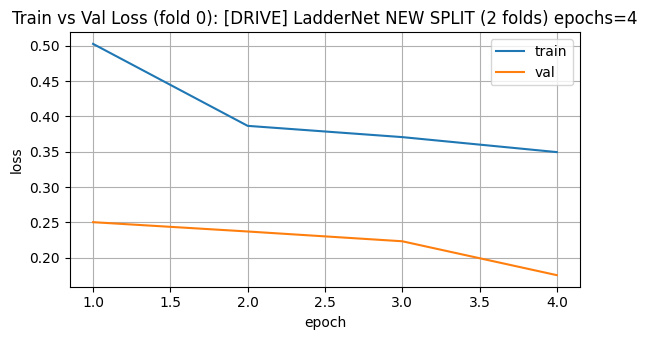

	 TRAIN vs VAL SAVED TO: ..\..\..\..\pth\LadderNet_DRIVE_NEWSPLIT\visuals\TrainVsVal__fold00.png


C:\Users\s1005\AppData\Local\Temp\ipykernel_43388\3288124053.py:119: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt_path, map_location=D

=== Test Set Evaluation Metrics ===
-- Macro (per-image mean) --
Sensitivity    : 0.1241
Specificity    : 0.9998
clDice         : 0.2352
Accuracy       : 0.9255
Dice           : 0.2168
IoU            : 0.1236
Precision      : 0.9828
FPR            : 0.0002
FDR            : 0.0172
Dice_thin      : 0.1710
Dice_thick     : 0.0831
ROC_AUC        : 0.9103
PR_AUC         : 0.6938
-- Micro (pooled over all pixels) --
Sensitivity    : 0.1236
Specificity    : 0.9998
F1/Dice        : 0.2196
Accuracy       : 0.9255
IoU            : 0.1233
Precision      : 0.9805
FPR            : 0.0002
FDR            : 0.0195
ROC_AUC        : 0.9027
PR_AUC         : 0.6738


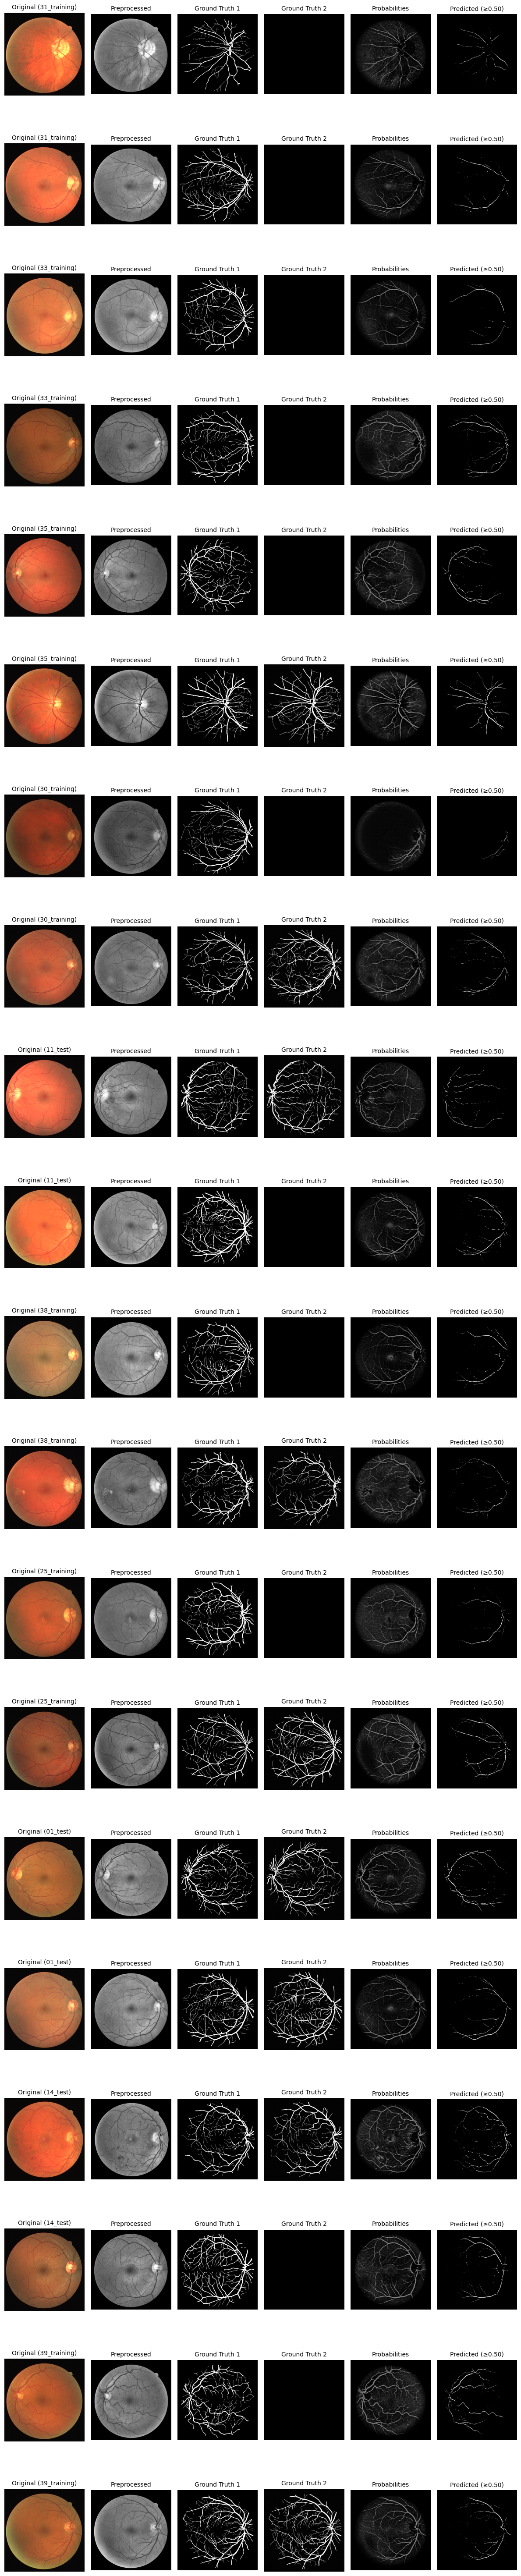

	== Visualization SAVED TO FILE: ..\..\..\..\pth\LadderNet_DRIVE_NEWSPLIT\visuals\testSet__fold00.png ==

========== LadderNet DRIVE NEW SPLIT, Fold 2/2 ==========

	 Chosen test subjects: [30, 7, 11, 27, 21, 5, 17, 8, 24, 35, 4, 38, 18, 22, 23, 0, 31, 39, 6, 2]

[F01 E001] train=0.4206 val=0.2538 lr=1.20e-04 time=9.1s
	CHECKPOINT SAVED: ..\..\..\..\pth\LadderNet_DRIVE_NEWSPLIT\checkpoints\DRIVE_fold01.pth
[F01 E002] train=0.3853 val=0.2316 lr=1.80e-04 time=10.1s
	CHECKPOINT SAVED: ..\..\..\..\pth\LadderNet_DRIVE_NEWSPLIT\checkpoints\DRIVE_fold01.pth
[F01 E003] train=0.3660 val=0.1911 lr=2.40e-04 time=10.5s
	CHECKPOINT SAVED: ..\..\..\..\pth\LadderNet_DRIVE_NEWSPLIT\checkpoints\DRIVE_fold01.pth
[F01 E004] train=0.2665 val=0.1155 lr=3.00e-04 time=9.8s
	CHECKPOINT SAVED: ..\..\..\..\pth\LadderNet_DRIVE_NEWSPLIT\checkpoints\DRIVE_fold01.pth


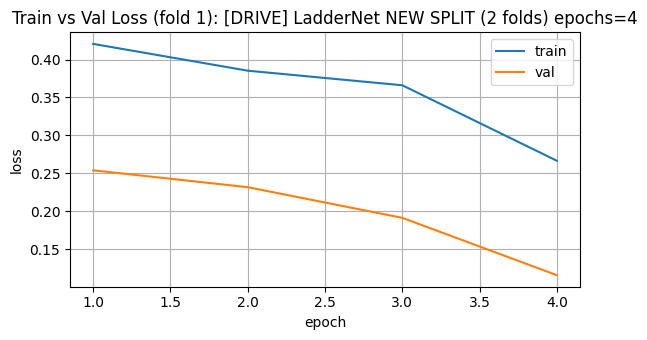

	 TRAIN vs VAL SAVED TO: ..\..\..\..\pth\LadderNet_DRIVE_NEWSPLIT\visuals\TrainVsVal__fold01.png


C:\Users\s1005\AppData\Local\Temp\ipykernel_43388\3288124053.py:119: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt_path, map_location=D

=== Test Set Evaluation Metrics ===
-- Macro (per-image mean) --
Sensitivity    : 0.5753
Specificity    : 0.9913
clDice         : 0.6568
Accuracy       : 0.9562
Dice           : 0.6841
IoU            : 0.5234
Precision      : 0.8640
FPR            : 0.0087
FDR            : 0.1360
Dice_thin      : 0.3833
Dice_thick     : 0.5819
ROC_AUC        : 0.9558
PR_AUC         : 0.8002
-- Micro (pooled over all pixels) --
Sensitivity    : 0.5746
Specificity    : 0.9913
F1/Dice        : 0.6884
Accuracy       : 0.9562
IoU            : 0.5249
Precision      : 0.8583
FPR            : 0.0087
FDR            : 0.1417
ROC_AUC        : 0.9543
PR_AUC         : 0.7927


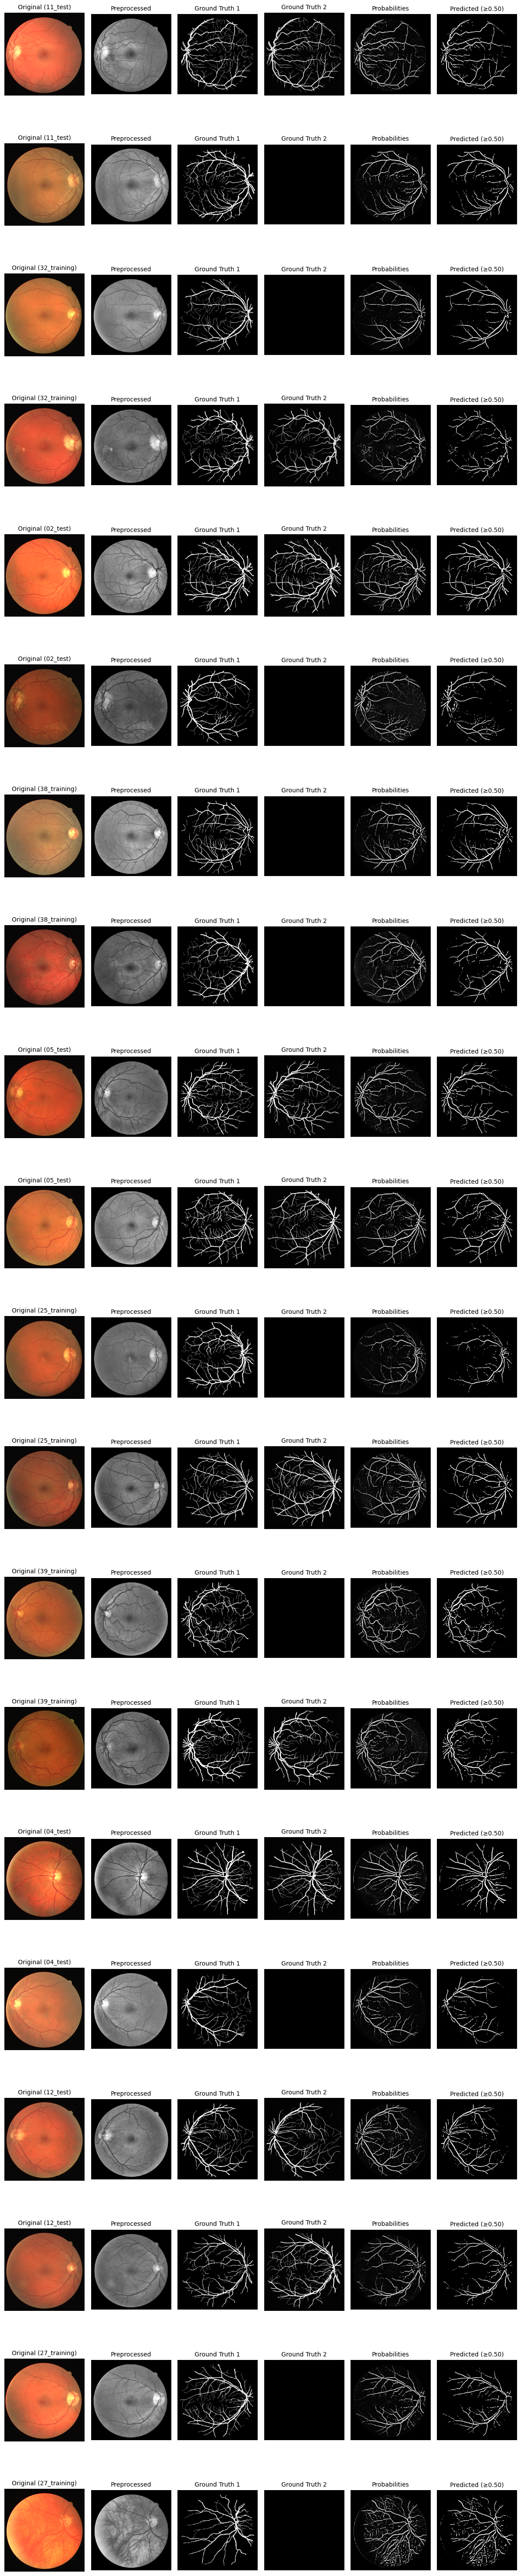

	== Visualization SAVED TO FILE: ..\..\..\..\pth\LadderNet_DRIVE_NEWSPLIT\visuals\testSet__fold01.png ==

=== LadderNet DRIVE NEW SPLITS (2 folds) — mean ± std ===
SEN: 0.3497 ± 0.3190
SPE: 0.9955 ± 0.0060
CLDICE: 0.4460 ± 0.2981
ACC: 0.9409 ± 0.0217
Dice: 0.4505 ± 0.3304
IoU: 0.3235 ± 0.2827
AUC: 0.9330 ± 0.0322
AP: 0.7470 ± 0.0752


In [10]:

all_metrics, summary = run_drive_experiment(
    model_name=MODEL_NAME,
    dataset=DATASET,
    V_MULT=V_MULT,
    root=DATASET_ROOT,
    label_folder=DATASET_LABELFOLDER,
    epochs=EPOCHS,
    warmup=warmup_epochs,
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    patch_train=True,
    patch_size=PATCH_SIZE,
    vessel_bias_p=VESSEL_BIAS,
    threshold_eval=THRESHOLD_EVAL,
    folds=FOLDS,
    fold_id=FOLD_ID,   #starts at any fold_id

    chckpnt_paths= [
        #"/content/drive/MyDrive/UNet Testing Template src/comparative/pth/UNet_DRIVE_NEWSPLIT/checkpoints/DRIVE_fold00.pth",
         #"..\..\..\..\pth\FR-UNet_STARE_NEWSPLIT\checkpoints\STARE_fold00.pth",
         #"..\..\..\..\pth\FR-UNet_STARE_NEWSPLIT\checkpoints\STARE_fold01.pth",
         #"..\..\..\..\pth\FR-UNet_STARE_NEWSPLIT\checkpoints\STARE_fold02.pth"

    ]
)



In [11]:
MODEL_NAME_2 = "LWNet"

In [12]:

all_metrics, summary = run_drive_experiment(
    model_name=MODEL_NAME_2,
    dataset=DATASET,
    V_MULT=V_MULT,
    root=DATASET_ROOT,
    label_folder=DATASET_LABELFOLDER,
    epochs=EPOCHS,
    warmup=warmup_epochs,
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    patch_train=True,
    patch_size=PATCH_SIZE,
    vessel_bias_p=VESSEL_BIAS,
    threshold_eval=THRESHOLD_EVAL,
    folds=FOLDS,
    fold_id=FOLD_ID,   #starts at any fold_id

    chckpnt_paths= [
        #"/content/drive/MyDrive/UNet Testing Template src/comparative/pth/UNet_DRIVE_NEWSPLIT/checkpoints/DRIVE_fold00.pth",
         #"..\..\..\..\pth\FR-UNet_STARE_NEWSPLIT\checkpoints\STARE_fold00.pth",
         #"..\..\..\..\pth\FR-UNet_STARE_NEWSPLIT\checkpoints\STARE_fold01.pth",
         #"..\..\..\..\pth\FR-UNet_STARE_NEWSPLIT\checkpoints\STARE_fold02.pth"

    ]
)



[DRIVE] Run 00 TEST images: ['31_training.png', '27_training.png', '33_training.png', '40_training.png', '35_training.png', '04_test.png', '30_training.png', '20_test.png', '11_test.png', '24_training.png', '38_training.png', '08_test.png', '25_training.png', '19_test.png', '01_test.png', '13_test.png', '14_test.png', '36_training.png', '39_training.png', '06_test.png']
[DRIVE] Run 01 TEST images: ['11_test.png', '28_training.png', '32_training.png', '08_test.png', '02_test.png', '26_training.png', '38_training.png', '29_training.png', '05_test.png', '16_test.png', '25_training.png', '19_test.png', '39_training.png', '03_test.png', '04_test.png', '21_training.png', '12_test.png', '20_test.png', '27_training.png', '23_training.png']
[DRIVE] Final per-image test counts: {0: 1, 1: 0, 2: 1, 3: 1, 4: 2, 5: 1, 6: 2, 7: 1, 8: 1, 9: 1, 10: 1, 11: 1, 12: 1, 13: 0, 14: 1, 15: 1, 16: 0, 17: 2, 18: 2, 19: 1, 20: 1, 21: 1, 22: 1, 23: 2, 24: 1, 25: 1, 26: 0, 27: 2, 28: 0, 29: 0, 30: 2, 31: 1, 32: 1,

RuntimeError: Given groups=1, weight of size [8, 2, 3, 3], expected input[2, 3, 128, 128] to have 2 channels, but got 3 channels instead